In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import chi2, VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

BLUE  = '#4CBBF0'
RED   = '#F06A6A'
GREEN = '#6BCB77'
GOLD  = '#FFD166'


# 1. CHARGEMENT DU DATASET PREPROCESSÉ

In [5]:
df = pd.read_csv("diabetic_data_preprocessed.csv")

target_cols = ['readmitted_bin', 'change_bin']

print(f"  Dimensions     : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"  Valeurs NaN    : {df.isnull().sum().sum()}")
print(f"  Cibles         : {target_cols}")
print(f"\n  Aperçu des colonnes :")
print(f"  {df.columns.tolist()}")


  Dimensions     : 101,763 lignes × 69 colonnes
  Valeurs NaN    : 0
  Cibles         : ['readmitted_bin', 'change_bin']

  Aperçu des colonnes :
  ['patient_nbr', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'diabetesMed', 'readmitted_bin', 'change_bin', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_Unknown', 'diag_1_Blessure', 'diag_1_Circulatoire', 'diag_1_Diabète', 'diag_1_Dige

# 2. CRÉATION DE NOUVELLES FEATURES

**Objectif** : enrichir le dataset avec des variables synthétiques
qui capturent des patterns médicaux non directement exprimés
dans les données brutes.

**Principe** : chaque nouvelle variable doit avoir une interprétation
clinique claire et apporter une information non redondante.

In [6]:
df_fe = df.copy()

###  Feature Engineering — Variables liées aux médicaments

#### 1. Données de départ

Les **21 colonnes de médicaments** ont été encodées en Phase 2 avec un **OrdinalEncoder** :

| Valeur | Encodage | Signification           |
| ------ | -------- | ----------------------- |
| No     | 0        | Médicament non prescrit |
| Steady | 1        | Dose stable             |
| Down   | 2        | Dose diminuée           |
| Up     | 3        | Dose augmentée          |

---

#### 2.  Création de nouvelles variables (features)

À partir de ces colonnes, on crée deux variables synthétiques :

---

#####  `nb_meds_actifs`

 Nombre de médicaments **actifs** (valeur > 0)

```python
(df_fe[colonnes_medicaments] > 0).sum(axis=1)
```

 Interprétation :

* Compte tous les médicaments **prescrits**
* Ignore ceux à 0 (non utilisés)

 Utilité :

* Mesure la **complexité du traitement**
* Plus ce nombre est élevé → traitement plus lourd → patient potentiellement plus à risque

---

#####  `nb_meds_modifies`

 Nombre de médicaments avec **dose modifiée** (Down ou Up)

```python
(df_fe[colonnes_medicaments] >= 2).sum(axis=1)
```

 Interprétation :

* Compte uniquement les changements (2 = Down, 3 = Up)
* Ignore les médicaments stables ou non prescrits

 Utilité :

* Mesure l’**instabilité du traitement**
* Beaucoup de changements → situation médicale instable

---

#### 3.  Attention : Data Leakage

Ces deux variables sont **très corrélées avec la cible `change_bin`** :

* `change_bin` = indique s’il y a eu un changement de traitement
* `nb_meds_modifies` = compte exactement ces changements

Donc :

Le modèle pourrait “tricher” en apprenant directement la réponse

---

#### 4. Décision importante

 Ces variables sont :

* **utiles pour l’analyse (EDA, compréhension métier)**
*  **dangereuses pour la modélisation**

 Elles doivent être **supprimées avant l’entraînement du modèle**

---



## 2.1  FEATURES MÉDICAMENTS

In [7]:
colonnes_medicaments = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'insulin',
    'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone'
]
colonnes_medicaments = [c for c in colonnes_medicaments if c in df_fe.columns]

# Nombre de médicaments actifs (Steady=1, Down=2, Up=3 → tous > 0)
df_fe['nb_meds_actifs']   = (df_fe[colonnes_medicaments] > 0).sum(axis=1)

# Nombre de médicaments avec dose modifiée (Down=2 ou Up=3)
df_fe['nb_meds_modifies'] = (df_fe[colonnes_medicaments] >= 2).sum(axis=1)

print("  [MÉDICAMENTS] Features créées :")
print(f"    nb_meds_actifs   → min={df_fe['nb_meds_actifs'].min()}, "
      f"max={df_fe['nb_meds_actifs'].max()}, "
      f"moy={df_fe['nb_meds_actifs'].mean():.2f}")
print(f"    nb_meds_modifies → min={df_fe['nb_meds_modifies'].min()}, "
      f"max={df_fe['nb_meds_modifies'].max()}, "
      f"moy={df_fe['nb_meds_modifies'].mean():.2f}")

  [MÉDICAMENTS] Features créées :
    nb_meds_actifs   → min=0, max=6, moy=1.18
    nb_meds_modifies → min=0, max=4, moy=0.29


###  Conclusion

Ce feature engineering permet de :

* transformer des données complexes en **indicateurs simples et puissants**
* capturer :

  * la **charge thérapeutique** (`nb_meds_actifs`)
  * la **stabilité du traitement** (`nb_meds_modifies`)


## 2.2  FEATURES HOSPITALISATIONS

###  Feature Engineering — Hospitalisations

####  Objectif

Créer des variables plus **informatives** à partir des données existantes pour mieux représenter le comportement médical des patients.

---

####  Variables créées

**1. `total_visites_anterieures`**
+ Somme des visites passées (outpatient + emergency + inpatient)
+ Mesure la **fréquence des soins**
+ Indique si le patient est suivi régulièrement

---

**2. `ratio_urgences`**
+ Proportion de visites aux urgences
+ Distingue un patient **“urgence” vs “suivi programmé”**
+ Utile pour détecter des profils instables

---

**3. `est_patient_frequent`**
+  1 si ≥ 3 visites, sinon 0
+  Identifie les patients **chroniques**
+  Important pour la prédiction de réadmission

---

**4. `procedures_par_jour`**
 Nombre de procédures / durée d’hospitalisation
 Mesure l’**intensité des soins**
 Indicateur indirect de la **gravité du cas**

---

####  Points techniques

* Utilisation de `np.where` pour éviter les divisions par zéro
* Toutes ces variables sont dérivées de données historiques

---

####  Data Leakage

 Aucun risque ici
 Contrairement aux variables médicaments, ces features :

* ne contiennent pas directement la réponse
* sont donc **utilisables dans le modèle**

---



In [8]:
df_fe['total_visites_anterieures'] = (
    df_fe['number_outpatient'] +
    df_fe['number_emergency']  +
    df_fe['number_inpatient']
)

df_fe['ratio_urgences'] = np.where(
    df_fe['total_visites_anterieures'] > 0,
    df_fe['number_emergency'] / df_fe['total_visites_anterieures'],
    0
)

df_fe['est_patient_frequent'] = (df_fe['total_visites_anterieures'] >= 3).astype(int)

df_fe['procedures_par_jour'] = np.where(
    df_fe['time_in_hospital'] > 0,
    df_fe['num_procedures'] / df_fe['time_in_hospital'],
    0
)

print("\n  [HOSPITALISATIONS] Features créées :")
print(f"    total_visites_anterieures → moy={df_fe['total_visites_anterieures'].mean():.2f}")
print(f"    ratio_urgences            → moy={df_fe['ratio_urgences'].mean():.3f}")
print(f"    est_patient_frequent      → {df_fe['est_patient_frequent'].mean()*100:.1f}% de patients fréquents")
print(f"    procedures_par_jour       → moy={df_fe['procedures_par_jour'].mean():.3f}")


  [HOSPITALISATIONS] Features créées :
    total_visites_anterieures → moy=1.20
    ratio_urgences            → moy=0.064
    est_patient_frequent      → 15.7% de patients fréquents
    procedures_par_jour       → moy=0.177


###  Conclusion

Ces variables permettent de capturer :

* la **fréquence des hospitalisations**
* le **type de parcours patient**
* la **gravité des soins**



# 3. DÉTECTION ET SUPPRESSION DU DATA LEAKAGE

### Détection et suppression du Data Leakage

#### Qu’est-ce que le data leakage ?

Le **data leakage** se produit lorsqu’une variable contient directement ou indirectement l’information de la cible.

Résultat :

* le modèle “triche”
* performances artificiellement élevées
* modèle non généralisable en réalité

---

####  Variables concernées

**1. `nb_meds_modifies`**
+ Compte les changements de traitement
+ Très proche de `change_bin`
+ Fuite directe d’information

---

**2. `nb_meds_actifs`**
+ Nombre de médicaments prescrits
+ Information disponible **après décision médicale**
+ Peut introduire un biais

---

**3. `diabetesMed` (si présent)**
+  Indique si un traitement diabétique est donné
+ Information postérieure
+ Non utilisable pour prédiction

---

####  Détection du leakage

 On calcule la corrélation avec les cibles :

* Si corrélation élevée (|r| > 0.3)
*  Variable suspecte

 Permet d’identifier les variables problématiques de façon objective

---

####  Suppression

 Toutes les variables détectées comme leakage sont supprimées :

 Étape **obligatoire avant la modélisation**

---




### 3.1 Calcul des corrélations avec les cibles

In [14]:
leakage_candidates = ['nb_meds_actifs', 'nb_meds_modifies']
df_fe['diabetesMed'] = (df_fe['diabetesMed'] == 'Yes').astype(int)
if 'diabetesMed' in df_fe.columns:
    leakage_candidates.append('diabetesMed')

print("\n  Corrélations avec les cibles :")
for col in leakage_candidates:
    if col in df_fe.columns:
        corr_r = df_fe[col].corr(df_fe['readmitted_bin'])
        corr_c = df_fe[col].corr(df_fe['change_bin'])
        leakage_flag = "  LEAKAGE" if abs(corr_c) > 0.3 or abs(corr_r) > 0.3 else "✓"
        print(f"    {col:<25} | readmitted_bin: {corr_r:+.3f} | change_bin: {corr_c:+.3f}  {leakage_flag}")



  Corrélations avec les cibles :
    nb_meds_actifs            | readmitted_bin: +0.003 | change_bin: +0.712    LEAKAGE
    nb_meds_modifies          | readmitted_bin: +0.035 | change_bin: +0.636    LEAKAGE
    diabetesMed               | readmitted_bin: +nan | change_bin: +nan  ✓


### 3.2 Visualisation du leakage

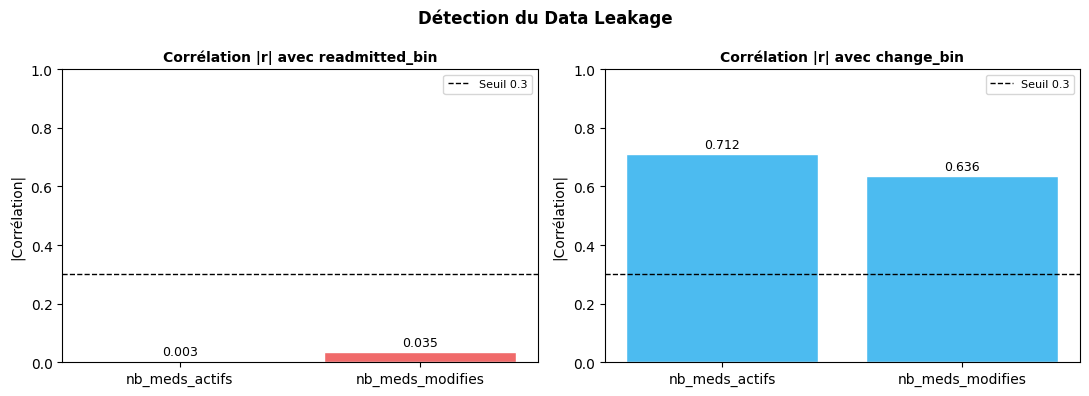

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, target, color in zip(axes, target_cols, [RED, BLUE]):
    leakage_corrs = {col: abs(df_fe[col].corr(df_fe[target]))
                     for col in leakage_candidates if col in df_fe.columns}
    ax.bar(leakage_corrs.keys(), leakage_corrs.values(),
           color=color, edgecolor='white', linewidth=1)
    ax.axhline(0.3, color='black', linestyle='--', linewidth=1, label='Seuil 0.3')
    ax.set_title(f'Corrélation |r| avec {target}', fontsize=10, fontweight='bold')
    ax.set_ylabel('|Corrélation|')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    for j, (col, val) in enumerate(leakage_corrs.items()):
        ax.text(j, val + 0.02, f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Détection du Data Leakage', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Suppression des colonnes leakage

In [17]:
leakage_cols_to_drop = [c for c in leakage_candidates if c in df_fe.columns]
df_fe = df_fe.drop(columns=leakage_cols_to_drop)

print(f"\n  Colonnes supprimées (data leakage) : {leakage_cols_to_drop}")
print(f"  Dimensions après suppression       : {df_fe.shape[0]:,} × {df_fe.shape[1]}")


  Colonnes supprimées (data leakage) : ['nb_meds_actifs', 'nb_meds_modifies', 'diabetesMed']
  Dimensions après suppression       : 101,763 × 72


###  Conclusion

Le data leakage est une erreur critique en machine learning

Dans ce projet :

* certaines variables sont utiles pour l’analyse
* mais doivent être supprimées avant entraînement

# 4. ANALYSE DE L'IMPORTANCE DES FEATURES

In [18]:
X_analysis = df_fe.drop(columns=target_cols)
y_analysis = df_fe[target_cols]


###4.1  CORRÉLATION DE PEARSON

### Corrélation de Pearson — Analyse des variables

####  Objectif

On calcule la **corrélation de Pearson** entre chaque variable numérique et les variables cibles :

- `readmitted_bin`
- `change_bin`

 Cette méthode permet de mesurer **la relation linéaire** entre une feature et une cible.

---

####  Principe

La corrélation de Pearson varie entre **-1 et +1** :

- **+1** → forte corrélation positive (les deux variables évoluent ensemble)
- **-1** → forte corrélation négative (évoluent en sens inverse)
- **0** → aucune relation linéaire

---

####  Méthodologie

- On sélectionne uniquement les **variables numériques**
- On calcule leur corrélation avec chaque cible
- On garde les **15 variables les plus corrélées** (en valeur absolue)

 Cela permet d’identifier les variables les plus influentes

---

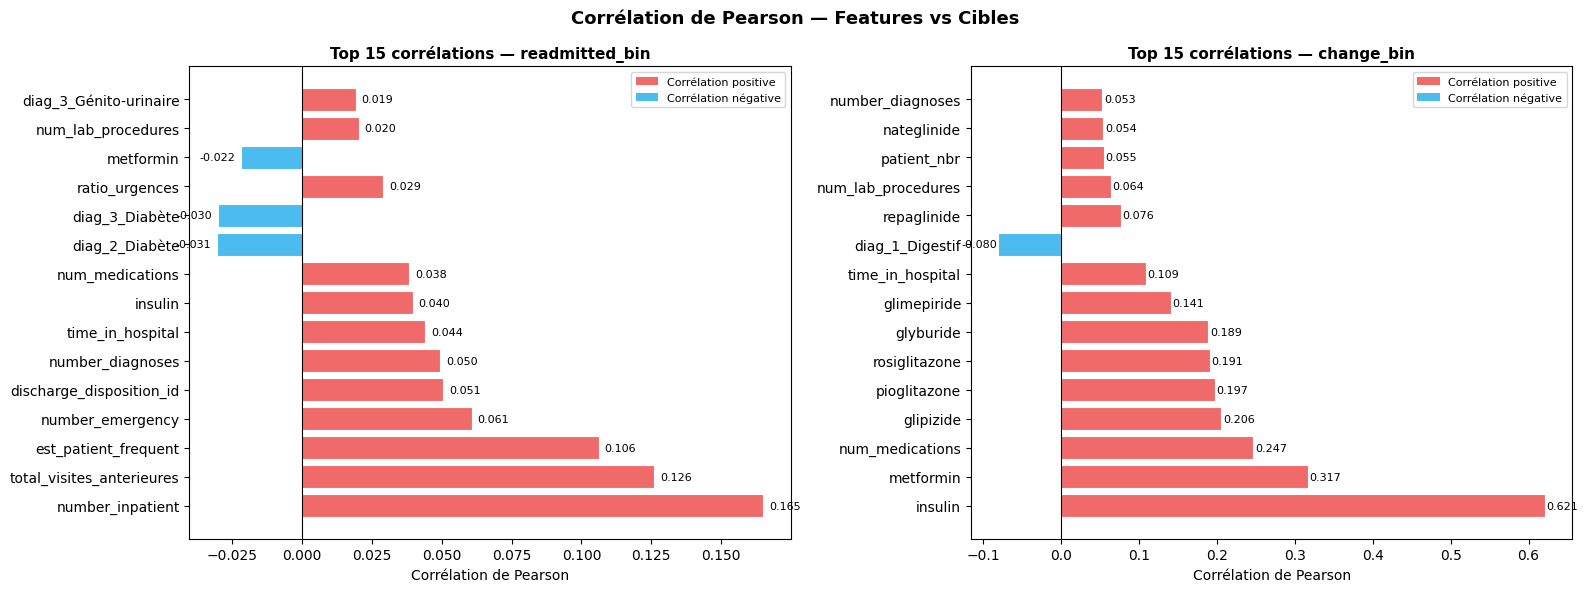


  Top 10 features corrélées avec readmitted_bin :
number_inpatient             0.1651
total_visites_anterieures    0.1261
est_patient_frequent         0.1063
number_emergency             0.0607
discharge_disposition_id     0.0506
number_diagnoses             0.0495
time_in_hospital             0.0442
insulin                      0.0397
num_medications              0.0384
diag_2_Diabète               0.0305

  Top 10 features corrélées avec change_bin :
insulin             0.6211
metformin           0.3165
num_medications     0.2468
glipizide           0.2060
pioglitazone        0.1974
rosiglitazone       0.1907
glyburide           0.1890
glimepiride         0.1409
time_in_hospital    0.1092
diag_1_Digestif     0.0804


In [19]:
# On prend uniquement les colonnes numériques pour Pearson
num_features = X_analysis.select_dtypes(include=['int64', 'float64']).columns.tolist()

corr_readmitted = df_fe[num_features + ['readmitted_bin']].corr()['readmitted_bin'].drop('readmitted_bin')
corr_change     = df_fe[num_features + ['change_bin']].corr()['change_bin'].drop('change_bin')

# Top 15 features par corrélation absolue avec readmitted_bin
top15_r = corr_readmitted.abs().sort_values(ascending=False).head(15)
top15_c = corr_change.abs().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, top15, corr_vals, target, color in zip(
        axes,
        [top15_r, top15_c],
        [corr_readmitted, corr_change],
        target_cols,
        [RED, BLUE]):

    vals   = corr_vals[top15.index]
    colors = [RED if v > 0 else BLUE for v in vals.values]

    bars = ax.barh(top15.index, vals.values, color=colors, edgecolor='white', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Corrélation de Pearson')
    ax.set_title(f'Top 15 corrélations — {target}', fontsize=11, fontweight='bold')

    for bar, val in zip(bars, vals.values):
        offset = 0.002 if val >= 0 else -0.002
        ax.text(val + offset, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8)

    legend_elements = [
        mpatches.Patch(facecolor=RED,  label='Corrélation positive'),
        mpatches.Patch(facecolor=BLUE, label='Corrélation négative')
    ]
    ax.legend(handles=legend_elements, fontsize=8)

plt.suptitle("Corrélation de Pearson — Features vs Cibles",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n  Top 10 features corrélées avec readmitted_bin :")
print(corr_readmitted.abs().sort_values(ascending=False).head(10).round(4).to_string())
print("\n  Top 10 features corrélées avec change_bin :")
print(corr_change.abs().sort_values(ascending=False).head(10).round(4).to_string())

###  Conclusion

- Permet de **repérer rapidement les variables pertinentes**
- Aide à comprendre les relations entre variables et cibles
- Sert d’outil d’analyse, **pas de sélection finale automatique**

### 4.2  TEST DU CHI² (variables numériques entières)

###  Test du Chi² — Importance statistique des variables

####  Objectif

Le **test du Chi² (Chi-square)** permet de mesurer la **dépendance statistique** entre une variable et une cible catégorielle.

 Il répond à la question :  
**“Cette variable influence-t-elle réellement la cible ?”**

---

####  Principe

- **Hypothèse nulle (H0)** : la variable est **indépendante** de la cible  
- **p-value < 0.05** → on rejette H0 → la variable est **significative**

 Donc :

-  p-value < 0.05 → variable importante  
-  p-value ≥ 0.05 → variable peu pertinente

---

####  Méthodologie

- On sélectionne uniquement les **variables numériques positives**
  (car le test Chi² de sklearn ne fonctionne qu’avec des valeurs ≥ 0)

- On calcule pour chaque variable :
  - son **score Chi²**
  - sa **p-value**
  - si elle est **significative ou non**

- On affiche le **Top 10 des variables les plus importantes** pour chaque cible :
  - `readmitted_bin`
  - `change_bin`

---

####  Interprétation

- Le Chi² mesure une **relation statistique**, pas une corrélation linéaire
- Une variable peut être significative même si la corrélation est faible

Contrairement à Pearson :
- Pearson → relation **linéaire**
- Chi² → **dépendance globale** (catégorielle)

In [20]:
# Sélectionner colonnes entières non négatives
int_cols = [c for c in num_features
            if df_fe[c].dtype in ['int64', 'float64']
            and df_fe[c].min() >= 0]

X_chi2 = df_fe[int_cols].fillna(0)

chi2_results = {}
for target in target_cols:
    scores, p_vals = chi2(X_chi2, df_fe[target])
    chi2_results[target] = pd.DataFrame({
        'feature'  : int_cols,
        'chi2'     : scores,
        'p_value'  : p_vals,
        'significatif': p_vals < 0.05
    }).sort_values('chi2', ascending=False)

print("\n  Test Chi² — Top 10 features significatives :")
for target in target_cols:
    print(f"\n  [{target}]")
    print(chi2_results[target].head(10)[['feature', 'chi2', 'p_value', 'significatif']]
          .to_string(index=False))




  Test Chi² — Top 10 features significatives :

  [readmitted_bin]
                  feature         chi2       p_value  significatif
              patient_nbr 1.750553e+08  0.000000e+00          True
total_visites_anterieures 7.067083e+03  0.000000e+00          True
         number_inpatient 6.963940e+03  0.000000e+00          True
 discharge_disposition_id 1.952722e+03  0.000000e+00          True
         number_emergency 1.643233e+03  0.000000e+00          True
     est_patient_frequent 9.694780e+02 7.740097e-213          True
                  insulin 1.852978e+02  3.378956e-42          True
        number_outpatient 1.578916e+02  3.268279e-36          True
           diag_2_Diabète 8.906457e+01  3.821331e-21          True
           diag_3_Diabète 8.150042e+01  1.752239e-19          True

  [change_bin]
                  feature         chi2       p_value  significatif
              patient_nbr 8.430709e+09  0.000000e+00          True
                  insulin 4.545454e+04  0.000

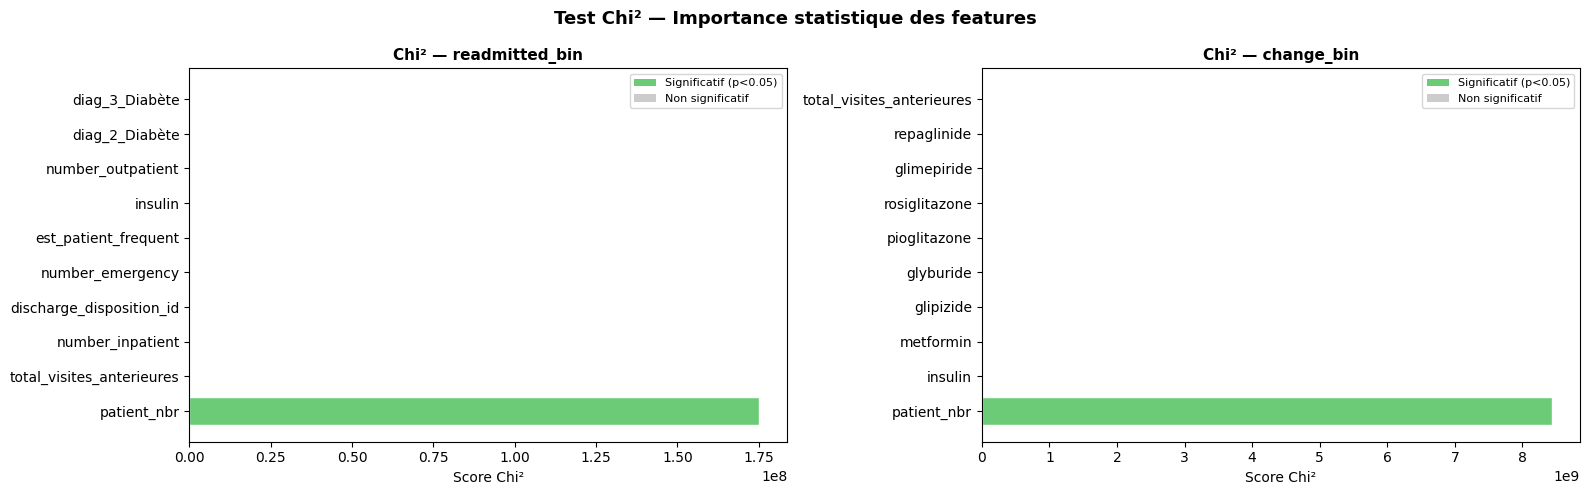

In [21]:
# Visualisation Chi²
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, target, color in zip(axes, target_cols, [RED, BLUE]):
    top10 = chi2_results[target].head(10)
    bar_colors = [GREEN if sig else '#CCCCCC' for sig in top10['significatif']]
    ax.barh(top10['feature'], top10['chi2'], color=bar_colors, edgecolor='white')
    ax.set_xlabel('Score Chi²')
    ax.set_title(f'Chi² — {target}', fontsize=11, fontweight='bold')

    sig_patch  = mpatches.Patch(facecolor=GREEN,   label='Significatif (p<0.05)')
    nsig_patch = mpatches.Patch(facecolor='#CCCCCC', label='Non significatif')
    ax.legend(handles=[sig_patch, nsig_patch], fontsize=8)

plt.suptitle("Test Chi² — Importance statistique des features",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###  Conclusion

- **`readmitted_bin`** :
  + Variables importantes = **historique des visites**  
  (visites antérieures, hospitalisations, urgences, type de sortie)  
  + La réadmission dépend du **profil médical du patient**

- **`change_bin`** :
  + Variables importantes = **médicaments**  
  + Logique car la cible mesure un **changement de traitement**

- **`patient_nbr`** :
  + Identifiant → **à supprimer** (pas d’intérêt médical)


### 4.3  VARIANCE — SUPPRESSION DES FEATURES QUASI-CONSTANTES

####  VarianceThreshold — Suppression des variables peu informatives

####  Objectif

Supprimer les variables ayant une **très faible variance**, car elles n’apportent presque **aucune information** au modèle.

---


####  Méthode utilisée

- `VarianceThreshold(threshold=0.01)`

 Cela signifie :

- Toutes les variables avec une variance **< 0.01** seront considérées comme **peu utiles**

---

####  Résultat

- `low_var_cols` → liste des variables à faible variance
- `variances` → classement des variables par variance

---

####  Visualisation

- Graphique des **20 variables avec la plus faible variance**
- Couleurs :
  -  Rouge → variance < 0.01 (à supprimer)
  -  Bleu → variance suffisante

- Ligne verticale = seuil **0.01**

---

####  Pourquoi supprimer ces variables ?

- Elles n’aident pas à distinguer les classes
- Elles peuvent :
  - ajouter du bruit
  - ralentir le modèle
  - dégrader les performances


  Features à faible variance (< 0.01) : ['nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'race_Asian', 'diag_1_Diabète']
  Nombre                             : 15


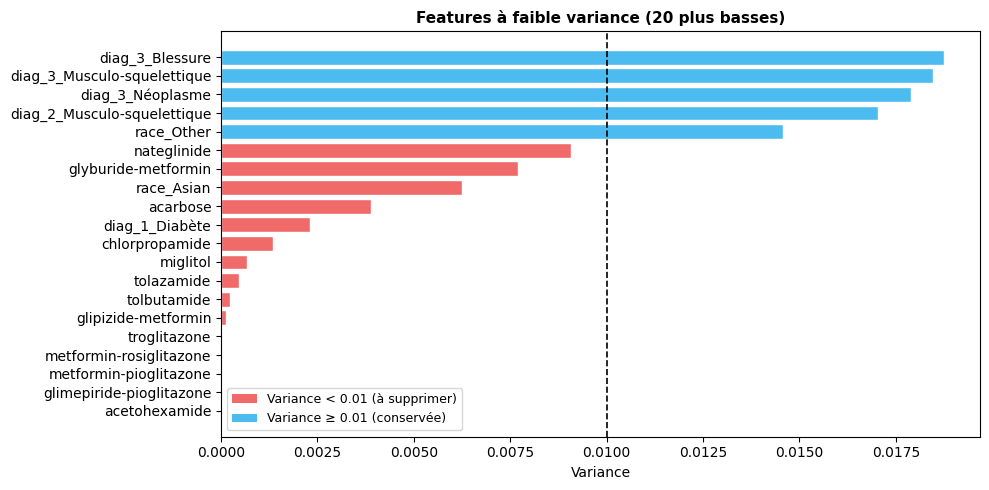

In [22]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_analysis.select_dtypes(include=['int64', 'float64']))

low_var_mask  = ~selector.get_support()
low_var_cols  = X_analysis.select_dtypes(include=['int64', 'float64']).columns[low_var_mask].tolist()
variances     = X_analysis.select_dtypes(include=['int64', 'float64']).var().sort_values()

print(f"\n  Features à faible variance (< 0.01) : {low_var_cols}")
print(f"  Nombre                             : {len(low_var_cols)}")

# Visualisation variances (bottom 20)
fig, ax = plt.subplots(figsize=(10, 5))
bottom20 = variances.head(20)
colors   = [RED if v < 0.01 else BLUE for v in bottom20.values]
ax.barh(bottom20.index, bottom20.values, color=colors, edgecolor='white')
ax.axvline(0.01, color='black', linestyle='--', linewidth=1.2, label='Seuil 0.01')
ax.set_xlabel('Variance')
ax.set_title('Features à faible variance (20 plus basses)', fontsize=11, fontweight='bold')
ax.legend()

low_patch  = mpatches.Patch(facecolor=RED,  label='Variance < 0.01 (à supprimer)')
high_patch = mpatches.Patch(facecolor=BLUE, label='Variance ≥ 0.01 (conservée)')
ax.legend(handles=[low_patch, high_patch], fontsize=9)
plt.tight_layout()
plt.show()

### 4.4  IMPORTANCE PAR RANDOM FOREST (feature importance globale)


####  Objectif

Évaluer l’importance de chaque variable dans la prédiction des cibles :

- `readmitted_bin`
- `change_bin`

Cette méthode permet de détecter les **relations complexes et non linéaires** que d’autres méthodes ne captent pas.

---

####  Méthode

- Utilisation d’un **Random Forest léger**
- Entraînement séparé pour chaque cible
- Paramètres :
  - `n_estimators = 100` → nombre d’arbres
  - `max_depth = 8` → contrôle la complexité
  - `class_weight = 'balanced'` → gère le déséquilibre
  - `n_jobs = -1` → calcul rapide (multi-core)

 Les variables utilisées :
- uniquement les **features numériques**
- valeurs manquantes remplacées par 0

---

####  Principe de l’importance

Le modèle calcule l’importance selon :

 **la réduction d’impureté (Gini)** apportée par chaque variable

- Plus une variable est utilisée dans les décisions → plus elle est importante
- Score élevé = variable très influente

---

####  Résultat

- `rf_importances` contient les scores d’importance
- Affichage du **Top 10** pour chaque cible

Permet de voir :
- quelles variables influencent le plus la prédiction
- quelles variables sont peu utiles

---

####  Pourquoi utiliser Random Forest ?

- Capture les **relations non linéaires**
- Plus fiable que :
  - Pearson (linéaire)
  - Chi² (statistique simple)



In [23]:
print("\n  Calcul de l'importance par Random Forest (rapide)...")

rf_importances = {}
X_rf = X_analysis.select_dtypes(include=['int64', 'float64']).fillna(0)

for target in target_cols:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )
    rf.fit(X_rf, df_fe[target])
    rf_importances[target] = pd.Series(
        rf.feature_importances_,
        index=X_rf.columns
    ).sort_values(ascending=False)




  Calcul de l'importance par Random Forest (rapide)...


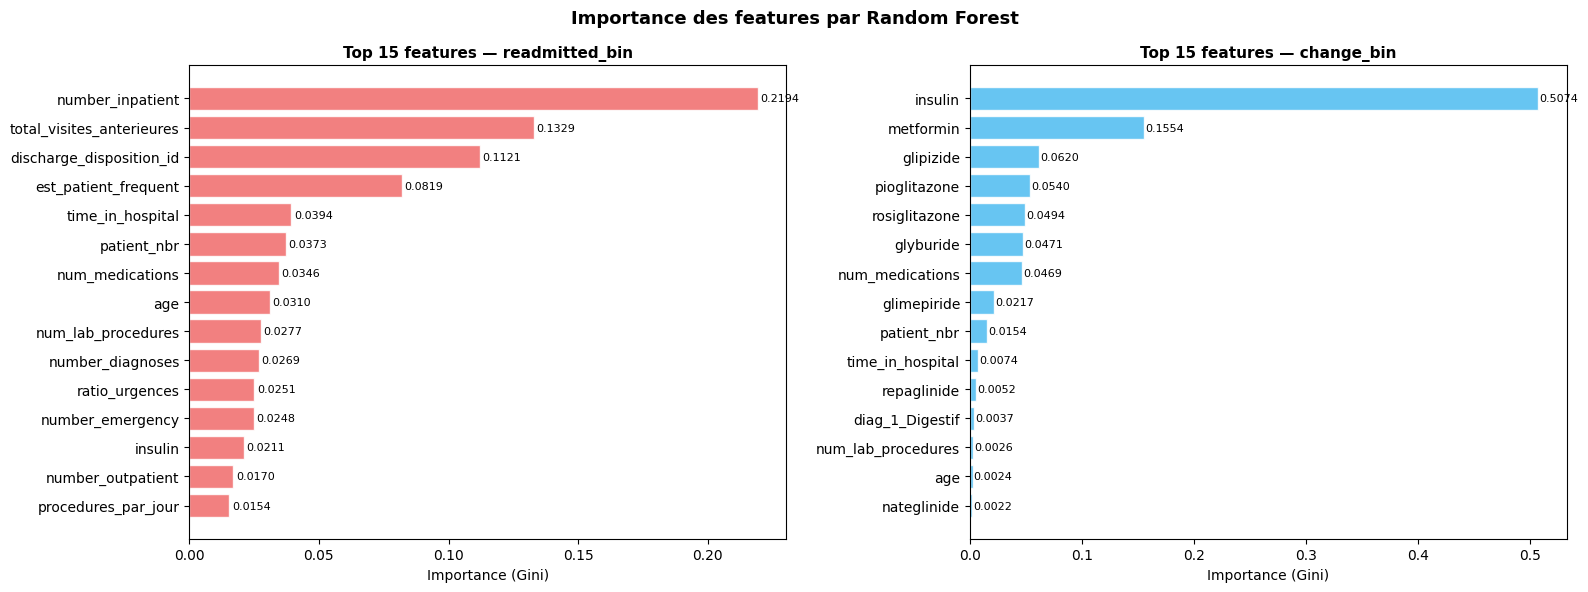


  Top 10 features importantes (readmitted_bin) :
number_inpatient             0.2194
total_visites_anterieures    0.1329
discharge_disposition_id     0.1121
est_patient_frequent         0.0819
time_in_hospital             0.0394
patient_nbr                  0.0373
num_medications              0.0346
age                          0.0310
num_lab_procedures           0.0277
number_diagnoses             0.0269

  Top 10 features importantes (change_bin) :
insulin             0.5074
metformin           0.1554
glipizide           0.0620
pioglitazone        0.0540
rosiglitazone       0.0494
glyburide           0.0471
num_medications     0.0469
glimepiride         0.0217
patient_nbr         0.0154
time_in_hospital    0.0074


In [24]:
# Visualisation top 15
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, target, color in zip(axes, target_cols, [RED, BLUE]):
    top15_rf = rf_importances[target].head(15)
    ax.barh(top15_rf.index[::-1], top15_rf.values[::-1],
            color=color, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Importance (Gini)')
    ax.set_title(f'Top 15 features — {target}', fontsize=11, fontweight='bold')
    for j, (feat, val) in enumerate(zip(top15_rf.index[::-1], top15_rf.values[::-1])):
        ax.text(val + 0.001, j, f'{val:.4f}', va='center', fontsize=8)

plt.suptitle("Importance des features par Random Forest",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n  Top 10 features importantes (readmitted_bin) :")
print(rf_importances['readmitted_bin'].head(10).round(4).to_string())
print("\n  Top 10 features importantes (change_bin) :")
print(rf_importances['change_bin'].head(10).round(4).to_string())

###  Résumé — Importance des variables (Random Forest)

- **`readmitted_bin`** :
  + Variables importantes = **historique hospitalier**  
  (hospitalisations, visites, type de sortie)  
  + La réadmission dépend du passé médical du patient

- **`change_bin`** :
  + Variables importantes = **médicaments**  
  + `insulin` est la variable la plus influente

- **`patient_nbr`** :
   Identifiant → à supprimer

---

###  Conclusion

- Résultats cohérents avec Chi²  
- Confirme les variables les plus importantes  
- Le modèle capture des relations complexes (non linéaires)

### 5.  SÉLECTION DES FEATURES FINALES

####  Critères de suppression

Une variable est supprimée si :

1. **Variance < 0.01**  
    variable presque constante → peu utile pour distinguer les patients

2. **Importance Random Forest < 0.001 (pour les 2 cibles)**  
    variable considérée comme du bruit

3. **Data leakage** (déjà supprimé avant)  
    variables qui contiennent indirectement la cible

---

####  Méthodologie

- On identifie :
  - `cols_low_var` → faible variance
  - `cols_low_imp` → faible importance dans les modèles RF

- On prend l’**union des deux listes**
- On supprime uniquement ces colonnes du dataset

---

In [25]:
# Features à faible variance
cols_low_var = low_var_cols

# Features à faible importance RF pour les deux cibles
imp_threshold = 0.001
cols_low_imp  = [
    col for col in X_rf.columns
    if (rf_importances['readmitted_bin'].get(col, 0) < imp_threshold and
        rf_importances['change_bin'].get(col, 0) < imp_threshold)
]

# Union des colonnes à supprimer (sans les cibles évidemment)
cols_to_drop_final = list(set(cols_low_var + cols_low_imp) - set(target_cols))

print(f"\n  Features supprimées (variance < 0.01)        : {len(cols_low_var)}")
print(f"  Features supprimées (importance RF < 0.001)  : {len(cols_low_imp)}")
print(f"  Total colonnes supprimées                    : {len(cols_to_drop_final)}")

if cols_to_drop_final:
    print(f"\n  Colonnes supprimées : {cols_to_drop_final}")
    df_fe = df_fe.drop(columns=[c for c in cols_to_drop_final if c in df_fe.columns])
else:
    print("\n  Aucune feature supprimée (toutes passent les critères).")
df_fe = df_fe.drop(columns=['patient_nbr'])

print(f"\n  Dimensions finales : {df_fe.shape[0]:,} lignes × {df_fe.shape[1]} colonnes")
print(f"  Features finales   : {df_fe.shape[1] - len(target_cols)}")


  Features supprimées (variance < 0.01)        : 15
  Features supprimées (importance RF < 0.001)  : 14
  Total colonnes supprimées                    : 15

  Colonnes supprimées : ['glyburide-metformin', 'glimepiride-pioglitazone', 'nateglinide', 'chlorpropamide', 'acarbose', 'metformin-rosiglitazone', 'acetohexamide', 'race_Asian', 'troglitazone', 'glipizide-metformin', 'diag_1_Diabète', 'metformin-pioglitazone', 'tolazamide', 'tolbutamide', 'miglitol']

  Dimensions finales : 101,763 lignes × 56 colonnes
  Features finales   : 54


### 6. RÉSUMÉ & SAUVEGARDE

In [26]:
print(f"\n   Aucune valeur manquante : {df_fe.isnull().sum().sum() == 0}")
print(f"   Cibles présentes        : {all(c in df_fe.columns for c in target_cols)}")
print(f"   Distribution des cibles :")
for target in target_cols:
    n_pos = df_fe[target].sum()
    print(f"       {target} : {n_pos:,} positifs ({n_pos/len(df_fe)*100:.1f}%)")


print(f"\n  BILAN FEATURE ENGINEERING :")
print(f"  ┌{'─'*40}┬{'─'*10}┐")
print(f"  │ {'Étape':<38} │ {'Colonnes':>8} │")
print(f"  ├{'─'*40}┼{'─'*10}┤")
print(f"  │ {'Chargement (Phase 2)':<38} │ {df.shape[1]:>8} │")
print(f"  │ {'+ Features médicaments':<38} │ {'+2':>8} │")
print(f"  │ {'+ Features hospitalisations':<38} │ {'+4':>8} │")
print(f"  │ {'+ Features interactions':<38} │ {'+2':>8} │")
print(f"  │ {'- Data leakage supprimé':<38} │ {f'-{len(leakage_cols_to_drop)}':>8} │")
print(f"  │ {'- Features à faible variance/imp.':<38} │ {f'-{len(cols_to_drop_final)}':>8} │")
print(f"  ├{'─'*40}┼{'─'*10}┤")
print(f"  │ {'TOTAL FINAL':<38} │ {df_fe.shape[1]:>8} │")
print(f"  └{'─'*40}┴{'─'*10}┘")

# Sauvegarde
output_path = 'diabetic_data_after_FE.csv'
df_fe.to_csv(output_path, index=False)

print(f"\n   Dataset sauvegardé : '{output_path}'")
print(f"     {df_fe.shape[0]:,} lignes × {df_fe.shape[1]} colonnes")
print("\n    Prochaine étape : Phase 4 — Modélisation & Évaluation")


   Aucune valeur manquante : True
   Cibles présentes        : True
   Distribution des cibles :
       readmitted_bin : 11,357 positifs (11.2%)
       change_bin : 47,009 positifs (46.2%)

  BILAN FEATURE ENGINEERING :
  ┌────────────────────────────────────────┬──────────┐
  │ Étape                                  │ Colonnes │
  ├────────────────────────────────────────┼──────────┤
  │ Chargement (Phase 2)                   │       69 │
  │ + Features médicaments                 │       +2 │
  │ + Features hospitalisations            │       +4 │
  │ + Features interactions                │       +2 │
  │ - Data leakage supprimé                │       -3 │
  │ - Features à faible variance/imp.      │      -15 │
  ├────────────────────────────────────────┼──────────┤
  │ TOTAL FINAL                            │       56 │
  └────────────────────────────────────────┴──────────┘

   Dataset sauvegardé : 'diabetic_data_after_FE.csv'
     101,763 lignes × 56 colonnes

    Prochaine étap